# Mora crediticia y actividad económica por sector

---

### Fuentes

| Dato | Fuente | URL | Frecuencia |
|------|--------|-----|------------|
| Préstamos por actividad (total y sit. normal) | BCRA – Boletín Estadístico | `https://www.bcra.gob.ar/Pdfs/PublicacionesEstadisticas/act{AÑO}.xls` | Trimestral |
| EMAE por sector | INDEC | `https://www.indec.gob.ar/ftp/cuadros/economia/sh_emae_actividad_base2004.xls` | Mensual |

### Definiciones

- **Irregularidad**: `(préstamos totales – préstamos en situación normal) / préstamos totales`. Incluye situaciones 2 a 6 del BCRA.
- La definición oficial del BCRA (Informe sobre Bancos) usa situaciones 3 a 6 solamente. Nuestra medida es más amplia pero consistente para comparación entre sectores.
- **Sectores**: clasificación CLANAE, match entre BCRA e INDEC a 13 sectores.

In [79]:
import xlrd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo para publicación
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'grid.linestyle': '--',
})

## 1. Cargar datos BCRA – Préstamos por actividad

In [80]:
# Mapeo de sectores BCRA -> letra CLANAE
# Orden = número de fila en el archivo act20XX.xls
SECTOR_MAP = {
    5:   ('A', 'Agro'),
    37:  ('B', 'Pesca'),
    38:  ('C', 'Minería'),
    45:  ('D', 'Industria'),
    80:  ('E', 'Elect/Gas/Agua'),
    87:  ('F', 'Construcción'),
    89:  ('G', 'Comercio'),
    95:  ('H', 'Hoteles/Rest.'),
    96:  ('I', 'Transporte'),
    102: ('J', 'Finanzas'),
    108: ('K', 'Inmob./Empresas'),
    114: ('L', 'Adm. Pública'),
    115: ('M+N', 'Educ./Salud'),
}

def parse_bcra(fname):
    """Parsea un archivo act20XX.xls y devuelve irregularidad por sector."""
    wb = xlrd.open_workbook(fname)
    sh = wb.sheet_by_name('Saldos')
    rows = []
    for r in range(26, sh.nrows):
        try:
            orden = int(sh.cell_value(r, 0))
            if orden not in SECTOR_MAP:
                continue
            fecha = sh.cell_value(r, 9)
            moneda = sh.cell_value(r, 10)
            if not isinstance(fecha, (int, float)) or fecha == 0:
                continue
            if not isinstance(moneda, (int, float)) or moneda != 0.0:
                continue
            total = sh.cell_value(r, 12)   # act00t
            normal = sh.cell_value(r, 39)  # act00n
            if not isinstance(total, (int, float)) or total <= 0:
                continue
            if not isinstance(normal, (int, float)):
                normal = 0
            fecha_str = str(int(fecha))
            letra, nombre = SECTOR_MAP[orden]
            rows.append({
                'fecha': pd.Timestamp(int(fecha_str[:4]), int(fecha_str[4:6]), int(fecha_str[6:])),
                'letra': letra,
                'sector': nombre,
                'total': total,
                'normal': normal,
                'irreg': (total - normal) / total * 100,
            })
        except Exception:
            continue
    return pd.DataFrame(rows)

# Cargar todos los años
bcra = pd.concat([parse_bcra(f'datos/act{y}.xls') for y in range(2020, 2026)], ignore_index=True)
bcra = bcra.sort_values(['letra', 'fecha']).reset_index(drop=True)

print(f"Observaciones: {len(bcra)}")
print(f"Períodos: {bcra.fecha.min().strftime('%Y-%m')} a {bcra.fecha.max().strftime('%Y-%m')}")
print(f"Sectores: {bcra.sector.nunique()}")
bcra.head()


Observaciones: 312
Períodos: 2020-03 a 2025-12
Sectores: 13


,fecha,letra,sector,total,normal,irreg
0,2020-03-31,A,Agro,280583840.0,262359525.0,6.495141
1,2020-06-30,A,Agro,329181858.0,311378236.0,5.408446
2,2020-09-30,A,Agro,360172298.0,340772195.0,5.386340
3,2020-12-31,A,Agro,420635037.0,400822867.0,4.710062
4,2021-03-31,A,Agro,408064939.0,386435819.0,5.300411


## 2. Cargar EMAE por sector

In [81]:
# EMAE
wb_emae = xlrd.open_workbook('datos/emae_actividad.xls')
sh = wb_emae.sheet_by_name('Tabla Letras')

# Mapeo de columna EMAE -> letra CLANAE
EMAE_COLS = {
    2: 'A', 3: 'B', 4: 'C', 5: 'D', 6: 'E', 7: 'F',
    8: 'G', 9: 'H', 10: 'I', 11: 'J', 12: 'K', 13: 'L',
    14: 'M', 15: 'N',
}

MONTHS = {'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,
          'Julio':7,'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12}

rows_emae = []
current_year = None
for r in range(5, sh.nrows):
    y = sh.cell_value(r, 0)
    m = str(sh.cell_value(r, 1)).strip()
    if isinstance(y, float) and y > 2000:
        current_year = int(y)
    if m not in MONTHS or current_year is None:
        continue
    row = {'year': current_year, 'month': MONTHS[m]}
    for col, letra in EMAE_COLS.items():
        val = sh.cell_value(r, col)
        if isinstance(val, (int, float)):
            row[letra] = val
    rows_emae.append(row)

emae = pd.DataFrame(rows_emae)
emae['date'] = pd.to_datetime(emae[['year', 'month']].assign(day=1))

# Para M+N: promedio simple de Enseñanza y Salud
emae['M+N'] = (emae['M'] + emae['N']) / 2

print(f"EMAE: {emae.date.min().strftime('%Y-%m')} a {emae.date.max().strftime('%Y-%m')}")
emae.tail()


EMAE: 2004-01 a 2026-01


,year,month,A,B,C,D,E,F,G,H,I,J,K,L,M,N,date,M+N
260,2025,9,76.099724,268.761566,125.143969,124.017034,139.089658,138.909146,154.680211,166.201969,186.281802,222.657584,161.054148,162.390676,175.473161,182.369971,2025-09-01,178.921566
261,2025,10,67.713893,100.603304,128.025901,130.535074,138.541676,135.327117,160.317956,183.018757,187.954943,209.651341,163.388912,161.457444,175.014879,177.630467,2025-10-01,176.322673
262,2025,11,87.580858,102.576456,121.866289,120.226675,138.376018,125.098002,150.100264,188.074293,185.966352,194.760088,158.879179,161.755373,175.090523,176.750441,2025-11-01,175.920482
263,2025,12,142.540866,118.268795,129.459699,117.472938,159.992784,122.362211,148.678297,192.156806,186.335646,200.011343,163.410357,161.851875,175.992872,170.238191,2025-12-01,173.115532
264,2026,1,114.812454,225.574837,134.225872,104.137223,161.769018,134.848463,142.811351,190.509751,186.725493,197.518283,154.305264,161.391545,168.860839,188.473427,2026-01-01,178.667133


## 3. Promediar EMAE a trimestral y calcular variación Q4 YoY

In [82]:
# Promediar EMAE a trimestral
emae['quarter'] = (emae['month'] - 1) // 3 + 1
letras = ['A','B','C','D','E','F','G','H','I','J','K','L','M+N']
emae_q = emae.groupby(['year', 'quarter'])[letras].mean().reset_index()

# Para variación Q4 YoY, usar Q4 de cada año
emae_q4 = emae_q[emae_q.quarter == 4].copy()
emae_yoy = {}
for letra in letras:
    for i in range(1, len(emae_q4)):
        y = emae_q4.iloc[i]['year']
        val = emae_q4.iloc[i][letra]
        val_prev = emae_q4.iloc[i-1][letra]
        if val_prev > 0:
            emae_yoy.setdefault(int(y), {})[letra] = (val / val_prev - 1) * 100

print("Variación Q4 YoY EMAE disponible para:", sorted(emae_yoy.keys()))

Variación Q4 YoY EMAE disponible para: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [83]:
# Irregularidad Q4 YoY
bcra_q4 = bcra[bcra.fecha.dt.month == 12].copy()
bcra_q4['year'] = bcra_q4.fecha.dt.year

# Calcular cambio en irregularidad dic vs dic anterior (en pp)
scatter_data = []
for letra in letras:
    sub = bcra_q4[bcra_q4.letra == letra].sort_values('year')
    for i in range(1, len(sub)):
        y = sub.iloc[i]['year']
        irreg_now = sub.iloc[i]['irreg']
        irreg_prev = sub.iloc[i-1]['irreg']
        delta_irreg = irreg_now - irreg_prev
        
        if int(y) in emae_yoy and letra in emae_yoy[int(y)]:
            scatter_data.append({
                'year': int(y),
                'letra': letra,
                'sector': sub.iloc[i]['sector'],
                'irreg': irreg_now,
                'delta_irreg': delta_irreg,
                'emae_yoy': emae_yoy[int(y)][letra],
                'cartera_M': sub.iloc[i]['total'] / 1e6,
            })

df = pd.DataFrame(scatter_data)
print(f"Observaciones para scatter: {len(df)}")
print(f"Años: {sorted(df.year.unique())}")
df.sort_values(['year', 'sector'])

Observaciones para scatter: 65
Años: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,year,letra,sector,irreg,delta_irreg,emae_yoy,cartera_M
55,2021,L,Adm. Pública,0.116857,0.101811,11.797747,77.114051
0,2021,A,Agro,5.475926,0.765864,9.182665,570.294057
30,2021,G,Comercio,5.750250,-0.844727,7.154617,505.368596
25,2021,F,Construcción,7.797757,-0.135210,4.966900,122.098893
60,2021,M+N,Educ./Salud,4.412107,1.826655,3.788683,58.924587
...,...,...,...,...,...,...,...
19,2025,D,Industria,4.289942,2.764432,-5.038131,19553.684531
54,2025,K,Inmob./Empresas,7.246362,4.724372,2.004332,4201.977389
14,2025,C,Minería,1.082913,-0.075719,8.098382,5648.917887
9,2025,B,Pesca,8.282808,7.714872,10.567832,121.577601


## 4. Evolución de la irregularidad por sector

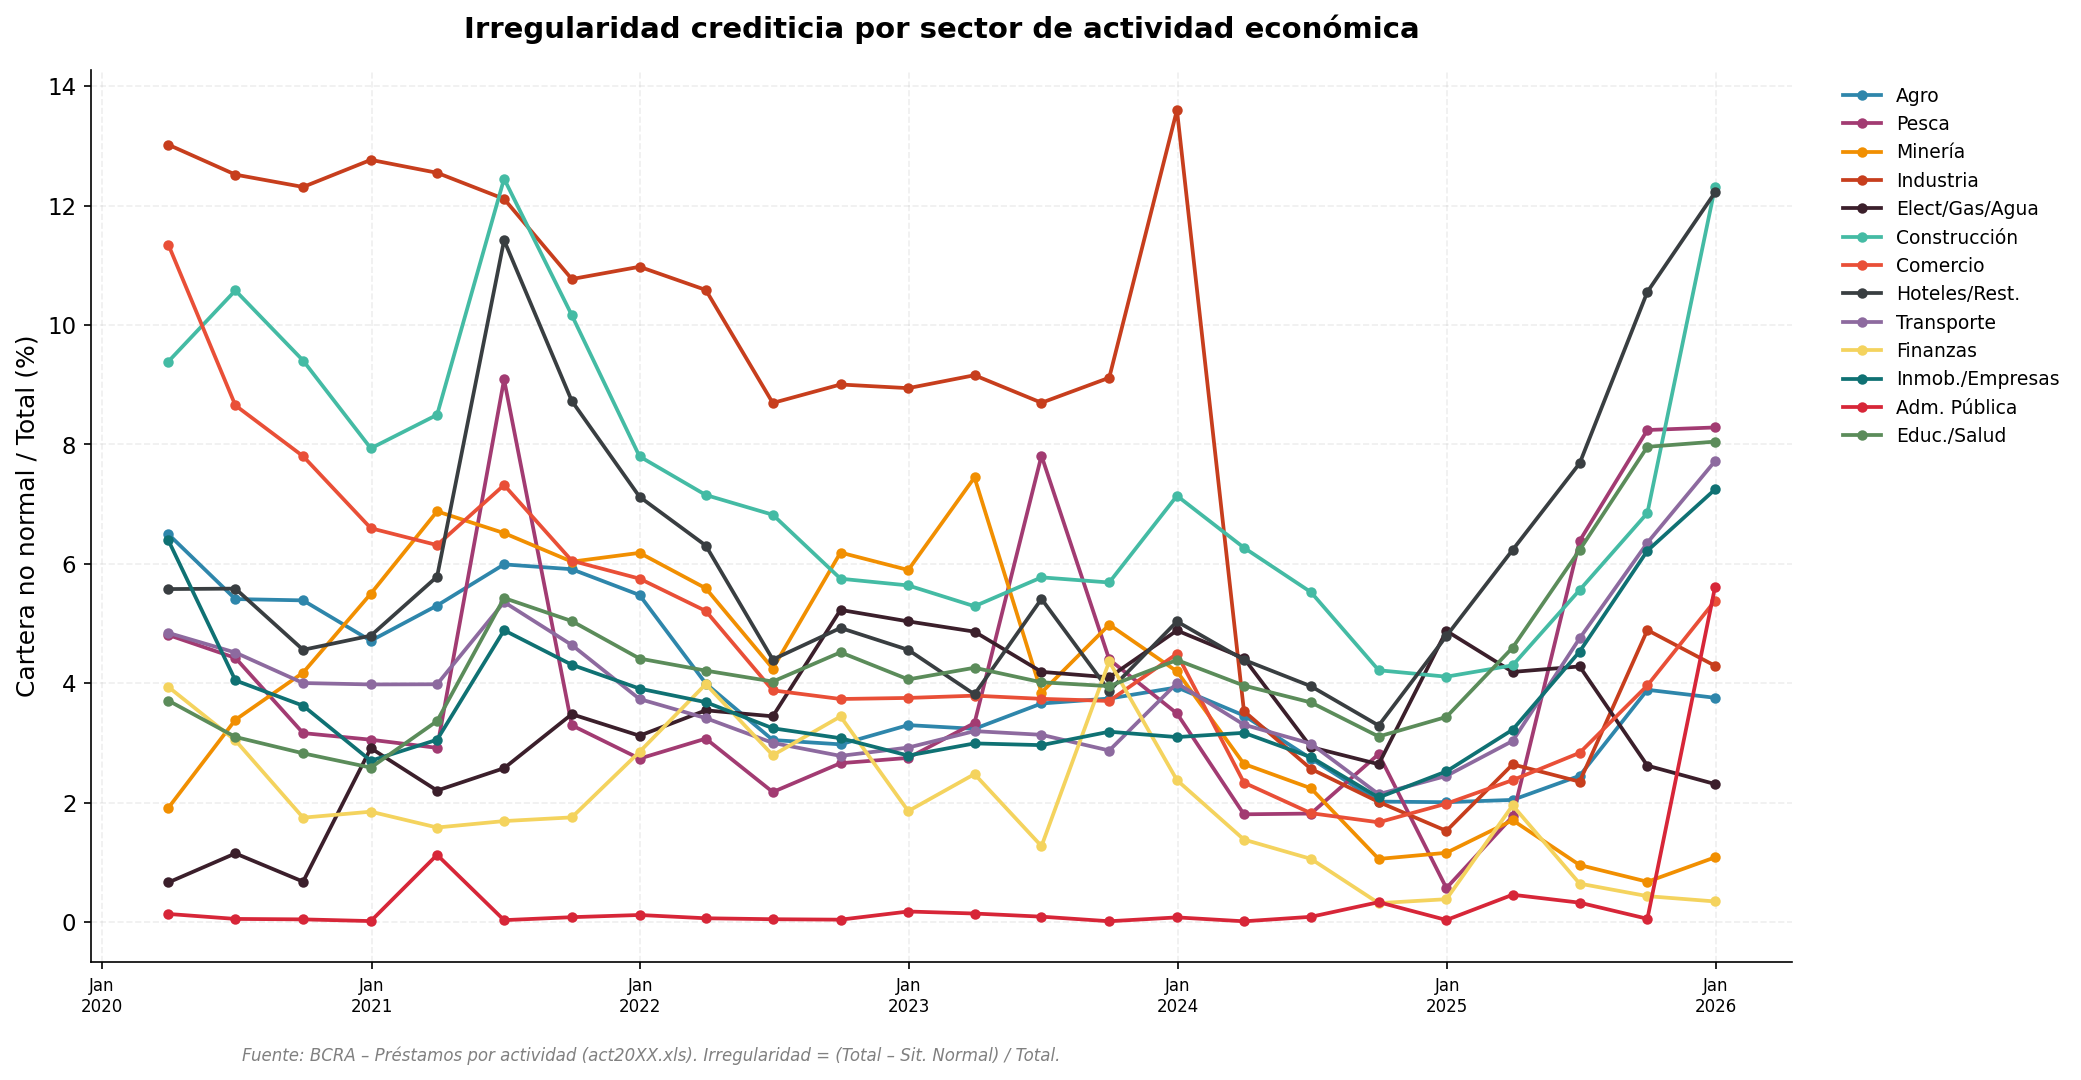

In [84]:
# Paleta de colores distinguibles
COLORS = {
    'Agro': '#2E86AB', 'Pesca': '#A23B72', 'Minería': '#F18F01',
    'Industria': '#C73E1D', 'Elect/Gas/Agua': '#3B1F2B', 'Construcción': '#44BBA4',
    'Comercio': '#E94F37', 'Hoteles/Rest.': '#393E41', 'Transporte': '#8D6A9F',
    'Finanzas': '#F4D35E', 'Inmob./Empresas': '#0F7173', 'Adm. Pública': '#D72638',
    'Educ./Salud': '#5B8C5A',
}

fig, ax = plt.subplots(figsize=(14, 7))

for sector in bcra.sector.unique():
    sub = bcra[bcra.sector == sector].sort_values('fecha')
    ax.plot(sub.fecha, sub.irreg, '-o', label=sector, color=COLORS.get(sector, 'gray'),
            markersize=4, linewidth=1.8)

ax.set_ylabel('Cartera no normal / Total (%)', fontsize=12)
ax.set_title('Irregularidad crediticia por sector de actividad económica',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=False)

# Formato de fechas
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)

# Fuente
fig.text(0.12, -0.02, 'Fuente: BCRA \u2013 Pr\u00e9stamos por actividad (act20XX.xls). Irregularidad = (Total \u2013 Sit. Normal) / Total.',
         fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('figuras/fig1_irregularidad_sectores.png', bbox_inches='tight', dpi=200)
plt.show()


## 5. Scatter: variación Q4 YoY de EMAE vs cambio en irregularidad

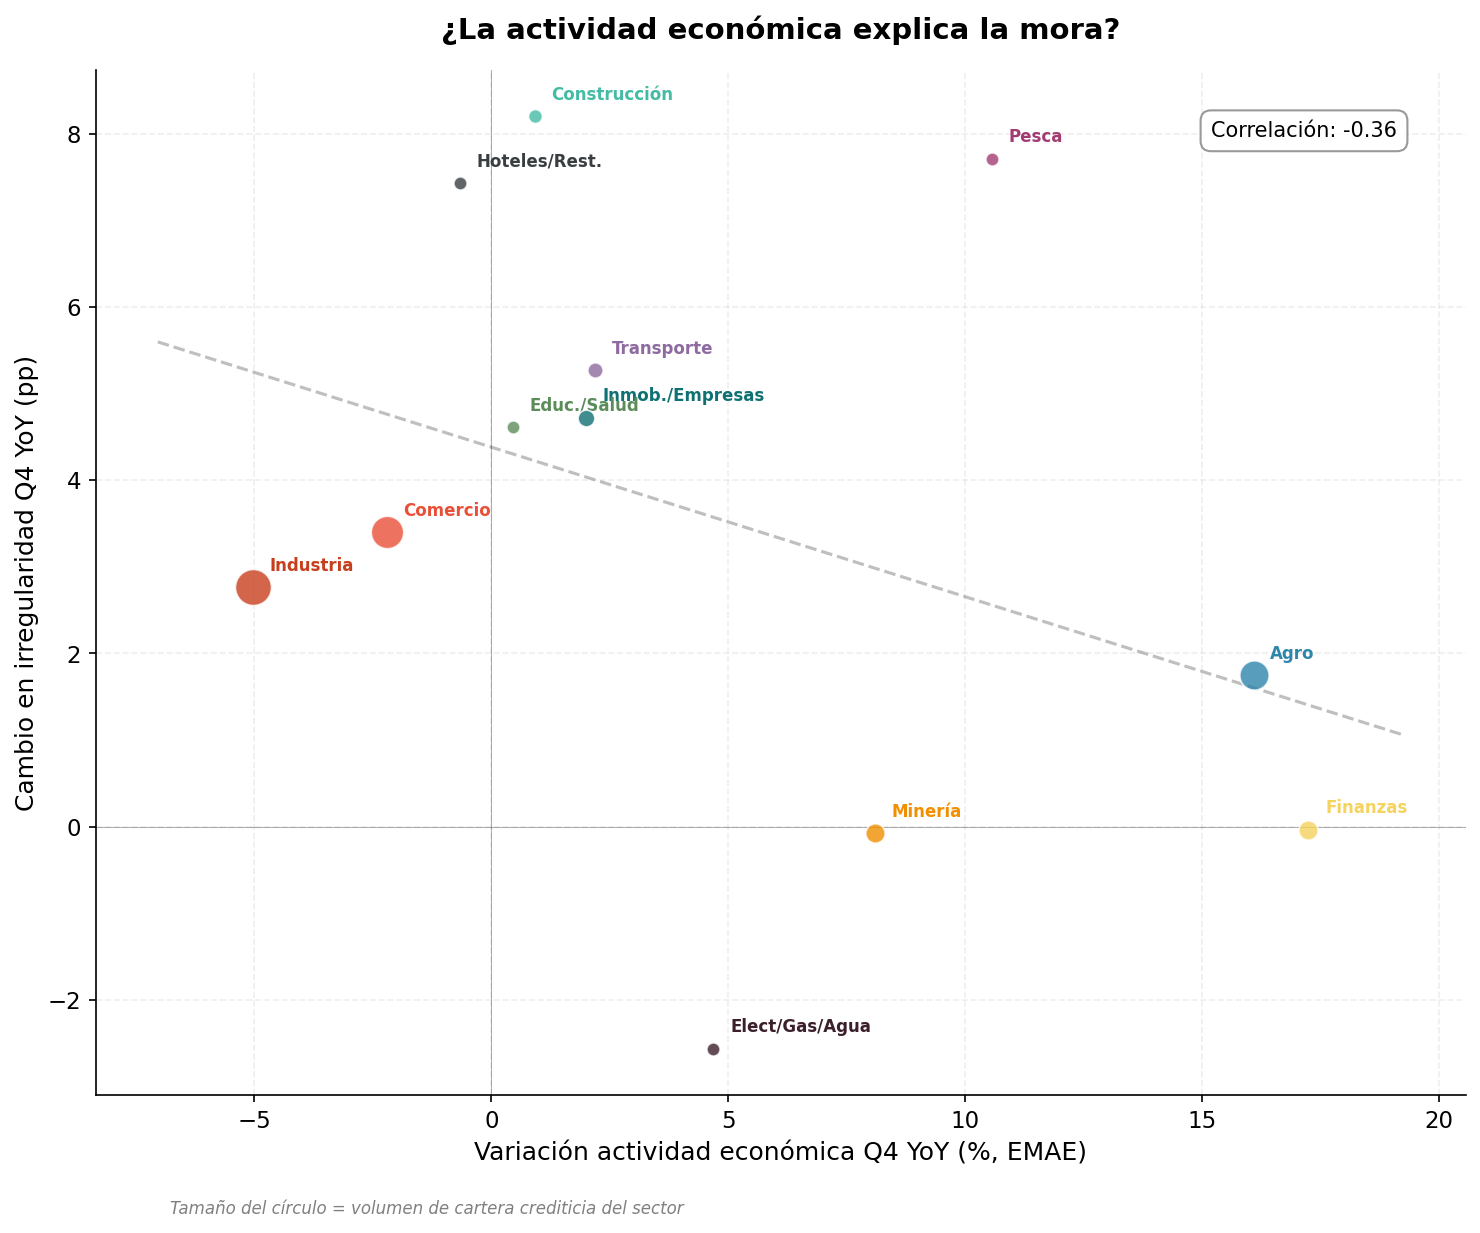

In [85]:
# Usar el último año disponible
latest_year = df.year.max()
df_latest = df[(df.year == latest_year) & (df.letra != 'L')].copy()

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter con tamaño proporcional a cartera
sizes = (df_latest.cartera_M / df_latest.cartera_M.max() * 300).clip(lower=40)

for _, row in df_latest.iterrows():
    color = COLORS.get(row['sector'], 'gray')
    s = max(40, row['cartera_M'] / df_latest.cartera_M.max() * 300)
    ax.scatter(row['emae_yoy'], row['delta_irreg'], s=s, color=color,
              alpha=0.8, edgecolors='white', linewidth=0.8, zorder=5)
    # Label
    ax.annotate(row['sector'],
               (row['emae_yoy'], row['delta_irreg']),
               fontsize=8, fontweight='bold',
               xytext=(8, 8), textcoords='offset points',
               color=color)

# Regresión
if len(df_latest) > 3:
    slope, intercept, r_value, p_value, _ = stats.linregress(df_latest['emae_yoy'], df_latest['delta_irreg'])
    x_line = np.linspace(df_latest['emae_yoy'].min() - 2, df_latest['emae_yoy'].max() + 2, 100)
    ax.plot(x_line, intercept + slope * x_line, '--', color='gray', alpha=0.5, linewidth=1.5)
    ax.text(0.95, 0.95, f'Correlaci\u00f3n: {r_value:+.2f}',
            transform=ax.transAxes, fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

# Ejes de referencia
ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)

ax.set_xlabel('Variación actividad económica Q4 YoY (%, EMAE)', fontsize=12)
ax.set_ylabel('Cambio en irregularidad Q4 YoY (pp)', fontsize=12)
ax.set_title(f'\u00bfLa actividad econ\u00f3mica explica la mora?',
             fontsize=14, fontweight='bold', pad=15)

# Nota: tamaño = volumen de cartera


fig.text(0.12, -0.02, 'Tama\u00f1o del c\u00edrculo = volumen de cartera crediticia del sector',
         fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('figuras/fig2_scatter_emae_mora.png', bbox_inches='tight', dpi=200)
plt.show()


## 6. Tabla resumen

In [86]:
tabla = df_latest[['sector', 'emae_yoy', 'irreg', 'delta_irreg', 'cartera_M']].copy()
tabla.columns = ['Sector', 'Var. EMAE (%)', 'Irregularidad (%)', '\u0394 Irreg (pp)', 'Cartera (M$)']
tabla = tabla.sort_values('\u0394 Irreg (pp)', ascending=False)
tabla = tabla.round(2)
tabla.style.format({'Cartera (M$)': '{:,.0f}'}).background_gradient(
    subset=['\u0394 Irreg (pp)'], cmap='RdYlGn_r'
).background_gradient(
    subset=['Var. EMAE (%)'], cmap='RdYlGn'
)

,Sector,Var. EMAE (%),Irregularidad (%),Δ Irreg (pp),Cartera (M$)
29,Construcción,0.920000,12.310000,8.210000,"2,897"
9,Pesca,10.570000,8.280000,7.710000,122
39,Hoteles/Rest.,-0.670000,12.220000,7.430000,436
44,Transporte,2.200000,7.720000,5.270000,"3,493"
54,Inmob./Empresas,2.000000,7.250000,4.720000,"4,202"
64,Educ./Salud,0.460000,8.050000,4.610000,"1,479"
34,Comercio,-2.210000,5.380000,3.400000,"15,805"
19,Industria,-5.040000,4.290000,2.760000,"19,554"
4,Agro,16.090000,3.750000,1.750000,"12,911"
49,Finanzas,17.250000,0.340000,-0.040000,"5,603"


## 7. Irregularidad agregada (sin Adm. Pública)

Serie trimestral de irregularidad agregada ponderada por cartera, excluyendo el sector L (Administración Pública).

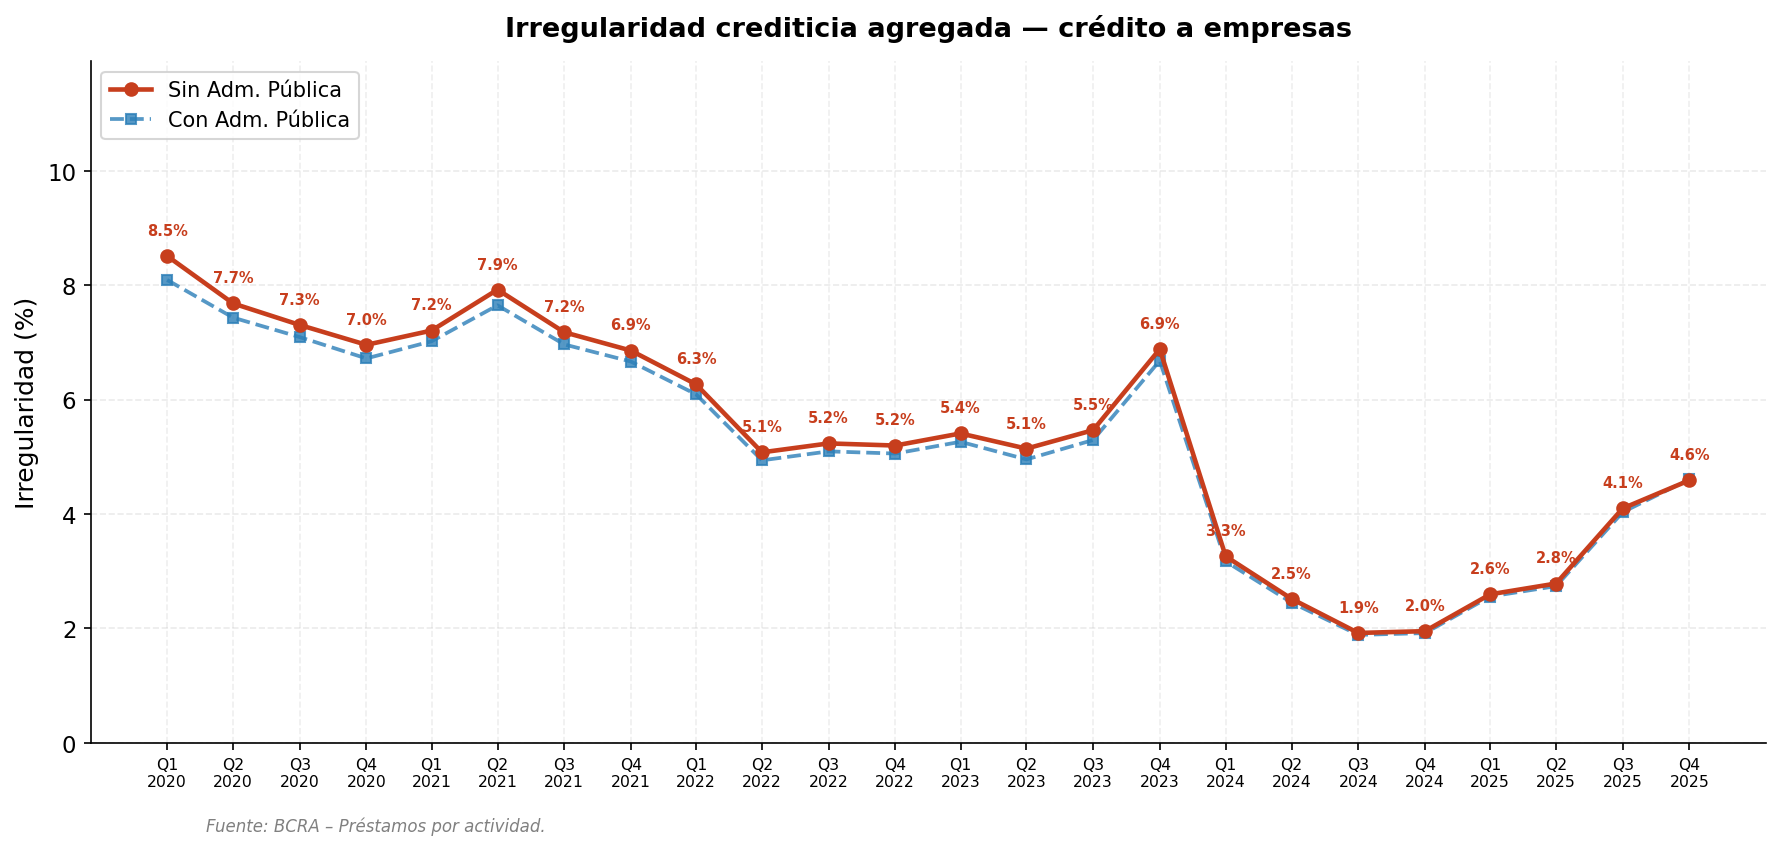

Sin Adm. Pública:
     fecha    irreg
2020-03-31 8.511970
2020-06-30 7.682148
2020-09-30 7.305466
2020-12-31 6.958066
2021-03-31 7.208098
2021-06-30 7.923206
2021-09-30 7.178410
2021-12-31 6.857970
2022-03-31 6.267302
2022-06-30 5.078341
2022-09-30 5.234253
2022-12-31 5.197296
2023-03-31 5.408785
2023-06-30 5.143258
2023-09-30 5.466110
2023-12-31 6.882551
2024-03-31 3.259859
2024-06-30 2.516366
2024-09-30 1.920066
2024-12-31 1.951592
2025-03-31 2.595511
2025-06-30 2.784549
2025-09-30 4.098704
2025-12-31 4.589785

Con Adm. Pública:
     fecha    irreg
2020-03-31 8.092568
2020-06-30 7.434039
2020-09-30 7.093243
2020-12-31 6.720229
2021-03-31 7.020736
2021-06-30 7.648951
2021-09-30 6.965658
2021-12-31 6.666055
2022-03-31 6.092483
2022-06-30 4.938755
2022-09-30 5.095177
2022-12-31 5.057220
2023-03-31 5.262883
2023-06-30 4.954305
2023-09-30 5.293980
2023-12-31 6.681951
2024-03-31 3.170877
2024-06-30 2.451175
2024-09-30 1.886370
2024-12-31 1.917594
2025-03-31 2.557388
2025-06-30 2.738908
202

In [87]:
# --- Irregularidad agregada: con y sin Adm. Pública ---
bcra_noL = bcra[bcra.letra != 'L'].copy()

agg_sinL = (bcra_noL.groupby('fecha')
            .agg(total=('total','sum'), normal=('normal','sum'))
            .reset_index())
agg_sinL['irreg'] = (agg_sinL['total'] - agg_sinL['normal']) / agg_sinL['total'] * 100

agg_conL = (bcra.groupby('fecha')
            .agg(total=('total','sum'), normal=('normal','sum'))
            .reset_index())
agg_conL['irreg'] = (agg_conL['total'] - agg_conL['normal']) / agg_conL['total'] * 100

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(agg_sinL.fecha, agg_sinL.irreg, 'o-', color='#C73E1D', linewidth=2.2,
        markersize=6, label='Sin Adm. Pública', zorder=5)
ax.plot(agg_conL.fecha, agg_conL.irreg, 's--', color='#2c7fb8', linewidth=1.8,
        markersize=5, label='Con Adm. Pública', alpha=0.8, zorder=4)

# Anotar valores (solo sin L)
for _, row in agg_sinL.iterrows():
    ax.annotate(f'{row.irreg:.1f}%',
                xy=(row.fecha, row.irreg),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=7, color='#C73E1D', fontweight='bold')

ax.set_ylabel('Irregularidad (%)', fontsize=12)
ax.set_title('Irregularidad crediticia agregada — crédito a empresas',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, max(agg_sinL.irreg.max(), agg_conL.irreg.max()) * 1.4)
ax.legend(fontsize=10, loc='upper left')

# Formato eje X
ax.set_xticks(agg_sinL.fecha)
ax.set_xticklabels([f'Q{d.quarter}\n{d.year}' for d in agg_sinL.fecha], fontsize=7.5)

ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.12, -0.02, 'Fuente: BCRA – Préstamos por actividad.',
         fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('figuras/fig3_irregularidad_agregada.png', dpi=200, bbox_inches='tight')
plt.show()

print('Sin Adm. Pública:')
print(agg_sinL[['fecha','irreg']].to_string(index=False))
print('\nCon Adm. Pública:')
print(agg_conL[['fecha','irreg']].to_string(index=False))

## 10. Crédito al sector privado / PIB (desde 2022)

**Fuentes:**
- **Crédito**: BCRA – Serie 26 *"Préstamos de las entidades financieras al sector privado"* (saldos diarios, en millones de ARS). Endpoint: `https://api.bcra.gob.ar/estadisticas/v4.0/Monetarias/26`
- **PIB**: INDEC – Cuentas Nacionales, PIB a precios de mercado, precios corrientes (trimestral anualizado, en millones de ARS). Vía datos.gob.ar (SSPM, dataset 8).

**Metodología**: promedio del stock diario de crédito en cada trimestre ÷ PIB trimestral (anualizado en la fuente). Convención estándar FMI/BM.

In [88]:
# --- 10a. Descargar crédito al sector privado (BCRA API, serie 26) ---
import urllib.request, json as _json, ssl

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

credito_records = []
for (desde, hasta) in [('2021-04-01','2023-06-30'), ('2023-07-01','2026-04-30')]:
    url = f'https://api.bcra.gob.ar/estadisticas/v4.0/Monetarias/26?desde={desde}&hasta={hasta}'
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, context=ctx) as resp:
        data = _json.loads(resp.read())
    # La API devuelve results[0]['detalle'] con la lista de {fecha, valor}
    credito_records.extend(data['results'][0]['detalle'])

credito = pd.DataFrame(credito_records)
credito['fecha'] = pd.to_datetime(credito['fecha'], dayfirst=True)
credito = credito.sort_values('fecha').rename(columns={'valor': 'credito_M'})
print(f'Crédito: {len(credito)} obs diarias, {credito.fecha.min().date()} a {credito.fecha.max().date()}')
print(f'Unidad: millones de ARS (fuente: BCRA API serie 26)')
credito.tail(3)

Crédito: 1223 obs diarias, 2021-04-05 a 2026-04-15
Unidad: millones de ARS (fuente: BCRA API serie 26)


,fecha,credito_M
550,2026-04-13,123592628.0
549,2026-04-14,124108891.0
548,2026-04-15,124325813.0


In [89]:
# --- 10b. Cargar PIB trimestral a precios corrientes ---
# NOTA: los valores trimestrales de datos.gob.ar ya están anualizados
# (cada trimestre ≈ PIB anual). NO hay que sumar 4 trimestres.
pib = pd.read_csv('datos/pib_trimestral_corrientes.csv')
pib = pib[['indice_tiempo', 'producto_interno_bruto_precios_mercado']].copy()
pib.columns = ['fecha', 'pib_M']
pib['fecha'] = pd.to_datetime(pib['fecha'])
pib = pib.sort_values('fecha').reset_index(drop=True)

# Filtrar desde 2022
pib = pib[pib.fecha >= '2021-04-01'].copy()
print(f'PIB trimestral: {len(pib)} obs, {pib.fecha.min().date()} a {pib.fecha.max().date()}')
print(f'Unidad: millones de ARS corrientes, anualizados (fuente: INDEC vía datos.gob.ar)')
pib.tail(3)


PIB trimestral: 19 obs, 2021-04-01 a 2025-10-01
Unidad: millones de ARS corrientes, anualizados (fuente: INDEC vía datos.gob.ar)


,fecha,pib_M
85,2025-04-01,8.337794e+08
86,2025-07-01,8.932770e+08
87,2025-10-01,9.394502e+08


In [90]:
# --- 10c. Promedio trimestral de crédito / PIB ---
# Convención estándar (FMI, BM, BCRA): promedio del stock en el período,
# no cierre. Esto evita sesgo en contextos de alta inflación.

credito['year'] = credito.fecha.dt.year
credito['quarter'] = credito.fecha.dt.quarter

# Promedio diario del stock dentro de cada trimestre
cred_q = (credito.groupby(['year','quarter'])['credito_M']
          .mean().reset_index())

# Fecha de inicio de trimestre para merge con PIB
q_month = {1: 1, 2: 4, 3: 7, 4: 10}
cred_q['fecha_q'] = cred_q.apply(
    lambda r: pd.Timestamp(year=int(r['year']), month=q_month[int(r['quarter'])], day=1), axis=1)

# Merge con PIB (ya anualizado en la fuente)
ratio = cred_q[['fecha_q', 'credito_M']].merge(
    pib[['fecha', 'pib_M']],
    left_on='fecha_q', right_on='fecha', how='inner'
)
ratio['cred_pib'] = ratio['credito_M'] / ratio['pib_M'] * 100  # en %

print(f'Serie crédito/PIB: {len(ratio)} observaciones trimestrales')
print(ratio[['fecha_q','credito_M','pib_M','cred_pib']].to_string(index=False))

Serie crédito/PIB: 19 observaciones trimestrales
   fecha_q    credito_M        pib_M  cred_pib
2021-04-01 3.484117e+06 4.634028e+07  7.518550
2021-07-01 3.742844e+06 4.746253e+07  7.885893
2021-10-01 4.258119e+06 5.428841e+07  7.843514
2022-01-01 4.691083e+06 6.034533e+07  7.773731
2022-04-01 5.353238e+06 7.867696e+07  6.804073
2022-07-01 6.225732e+06 8.786336e+07  7.085697
2022-10-01 7.055477e+06 1.043545e+08  6.761065
2023-01-01 8.036946e+06 1.207196e+08  6.657534
2023-04-01 1.005551e+07 1.592159e+08  6.315647
2023-07-01 1.242117e+07 2.065164e+08  6.014618
2023-10-01 1.638884e+07 2.831812e+08  5.787403
2024-01-01 2.078814e+07 4.234720e+08  4.908976
2024-04-01 2.815453e+07 5.599384e+08  5.028149
2024-07-01 4.133930e+07 6.428621e+08  6.430509
2024-10-01 5.616468e+07 7.093659e+08  7.917589
2025-01-01 7.163734e+07 7.239849e+08  9.894867
2025-04-01 8.710709e+07 8.337794e+08 10.447258
2025-07-01 1.020671e+08 8.932770e+08 11.426139
2025-10-01 1.119611e+08 9.394502e+08 11.917723


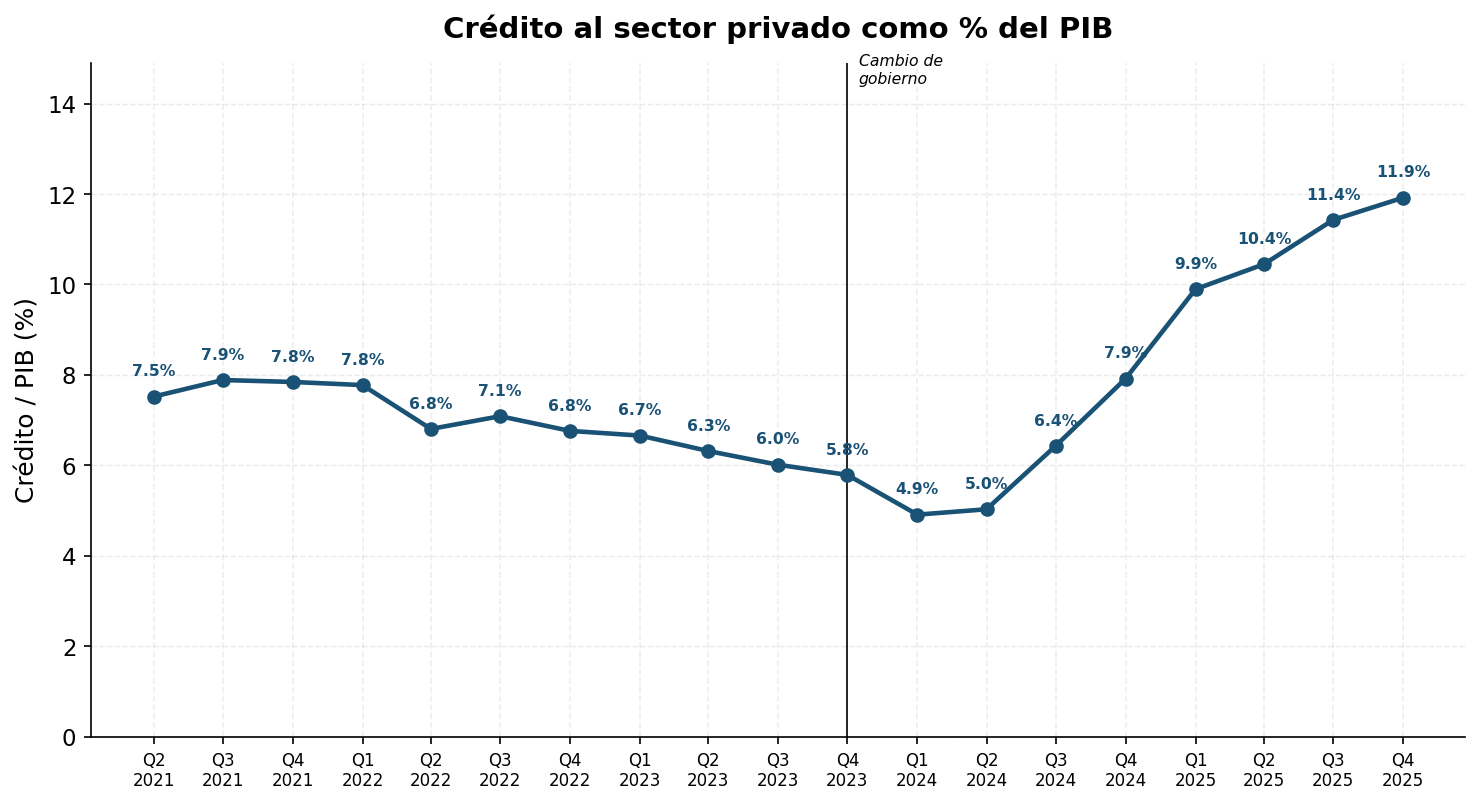

Trimestre Crédito (M ARS) PIB (M ARS) Crédito/PIB (%)
  Q2 2021       3,484,117  46,340,281            7.5%
  Q3 2021       3,742,844  47,462,529            7.9%
  Q4 2021       4,258,119  54,288,414            7.8%
  Q1 2022       4,691,083  60,345,325            7.8%
  Q2 2022       5,353,238  78,676,963            6.8%
  Q3 2022       6,225,732  87,863,364            7.1%
  Q4 2022       7,055,477 104,354,529            6.8%
  Q1 2023       8,036,946 120,719,557            6.7%
  Q2 2023      10,055,512 159,215,855            6.3%
  Q3 2023      12,421,172 206,516,400            6.0%
  Q4 2023      16,388,836 283,181,180            5.8%
  Q1 2024      20,788,141 423,472,034            4.9%
  Q2 2024      28,154,534 559,938,389            5.0%
  Q3 2024      41,339,305 642,862,095            6.4%
  Q4 2024      56,164,683 709,365,943            7.9%
  Q1 2025      71,637,339 723,984,892            9.9%
  Q2 2025      87,107,087 833,779,386           10.4%
  Q3 2025     102,067,069 89

In [91]:
# --- 10d. Gráfico y tabla: Crédito / PIB ---
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(ratio['fecha_q'], ratio['cred_pib'], 'o-',
        color='#1a5276', linewidth=2.2, markersize=6, zorder=3)

ax.set_ylabel('Crédito / PIB (%)', fontsize=12)
ax.set_xlabel('')
ax.set_title('Crédito al sector privado como % del PIB',
             fontsize=14, fontweight='bold', pad=12)

# Anotar valores
for i, row in ratio.iterrows():
    ax.annotate(f'{row.cred_pib:.1f}%',
                xy=(row.fecha_q, row.cred_pib),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=7.5, color='#1a5276',
                fontweight='bold')

ax.set_ylim(0, ratio['cred_pib'].max() * 1.25)
ax.grid(axis='y', alpha=0.25, linewidth=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Eje X: Q1 2022, Q2 2022, ...
labels = [f'Q{int(r.fecha_q.quarter)}\n{r.fecha_q.year}' for _, r in ratio.iterrows()]
ax.set_xticks(ratio['fecha_q'])
ax.set_xticklabels(labels, fontsize=8)

# Fuentes



# Hito: cambio de gobierno
cambio_gob = pd.Timestamp('2023-10-01')
ax.axvline(cambio_gob, color='black', linewidth=0.8, linestyle='-', zorder=2)
ax.text(cambio_gob + pd.Timedelta(days=15), ax.get_ylim()[1] * 0.97, 'Cambio de\ngobierno',
        ha='left', fontsize=7.5, color='black', style='italic')

plt.tight_layout()
plt.savefig('figuras/fig5_credito_pib.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Tabla resumen ---
tabla = ratio[['fecha_q','credito_M','pib_M','cred_pib']].copy()
tabla['Trimestre'] = tabla.fecha_q.apply(lambda d: f'Q{d.quarter} {d.year}')
tabla['Crédito (M ARS)'] = tabla.credito_M.apply(lambda x: f'{x:,.0f}')
tabla['PIB (M ARS)'] = tabla.pib_M.apply(lambda x: f'{x:,.0f}')
tabla['Crédito/PIB (%)'] = tabla.cred_pib.apply(lambda x: f'{x:.1f}%')
print(tabla[['Trimestre','Crédito (M ARS)','PIB (M ARS)','Crédito/PIB (%)']].to_string(index=False))


## 11. Intercepto y pendiente: ¿cambian con la inclusión financiera?

**Hipótesis**: en un período de baja inclusión financiera (cartera concentrada en tomadores seguros), el intercepto α de la regresión Δmora = α + β×ΔEMAE debería ser más bajo. El intercepto captura el cambio en mora *no explicado por actividad* — es decir, el efecto composición/calidad de cartera.

- **Baja inclusión** (Q2 2021 – Q3 2023): crédito/PIB ~6-7%, cartera estable.
- **Alta inclusión** (desde Q3 2024): crédito/PIB pasa de 6% a 12%, entrada masiva de nuevos tomadores.
- Q4 2023 – Q2 2024: período de transición, excluido.

In [92]:
# --- 11a. Construir variaciones interanuales trimestrales ---
from scipy import stats
import numpy as np

bcra_nopub = bcra[bcra.letra != 'L'].copy()
bcra_nopub['year'] = bcra_nopub.fecha.dt.year
bcra_nopub['quarter'] = bcra_nopub.fecha.dt.quarter
letras_nopub = [l for l in letras if l != 'L']

panel_rows = []
for letra in letras_nopub:
    sub_bcra = bcra_nopub[bcra_nopub.letra == letra].sort_values('fecha')
    sub_emae = emae_q[['year','quarter',letra]].copy()
    for _, row in sub_bcra.iterrows():
        y, q = row.year, row.quarter
        prev = sub_bcra[(sub_bcra.year == y-1) & (sub_bcra.quarter == q)]
        if prev.empty:
            continue
        delta_irreg = row.irreg - prev.iloc[0].irreg
        emae_now = sub_emae[(sub_emae.year == y) & (sub_emae.quarter == q)]
        emae_prev = sub_emae[(sub_emae.year == y-1) & (sub_emae.quarter == q)]
        if emae_now.empty or emae_prev.empty:
            continue
        emae_yoy_val = (emae_now.iloc[0][letra] / emae_prev.iloc[0][letra] - 1) * 100
        panel_rows.append({
            'year': y, 'quarter': q,
            'fecha_q': pd.Timestamp(y, [1,4,7,10][q-1], 1),
            'letra': letra, 'sector': row.sector,
            'irreg': row.irreg, 'delta_irreg': delta_irreg,
            'emae_yoy': emae_yoy_val, 'cartera': row.total,
        })

panel = pd.DataFrame(panel_rows)

def assign_periodo(d):
    if pd.Timestamp('2021-04-01') <= d <= pd.Timestamp('2023-07-01'):
        return 'Baja inclusión'
    elif d >= pd.Timestamp('2024-07-01'):
        return 'Alta inclusión'
    else:
        if d < pd.Timestamp('2021-04-01'):
            return 'Excluir'
        return 'Transición'
panel['periodo'] = panel.fecha_q.apply(assign_periodo)
panel = panel[panel.periodo != 'Excluir'].reset_index(drop=True)

print(f'Panel: {len(panel)} obs, {panel.fecha_q.nunique()} trimestres, {panel.letra.nunique()} sectores')
for p in ['Baja inclusión', 'Transición', 'Alta inclusión']:
    print(f'  {p}: {len(panel[panel.periodo==p])} obs')

Panel: 228 obs, 19 trimestres, 12 sectores
  Baja inclusión: 120 obs
  Transición: 36 obs
  Alta inclusión: 72 obs


### A. Rolling cross-sectional regressions (una por trimestre)

In [93]:
# --- 11b. Opción A: regresión cross-section por trimestre ---
reg_results = []
for fq in sorted(panel.fecha_q.unique()):
    sub = panel[panel.fecha_q == fq]
    if len(sub) < 5:
        continue
    slope, intercept, r, p, se = stats.linregress(sub.emae_yoy, sub.delta_irreg)
    reg_results.append({
        'fecha_q': fq,
        'trimestre': f'Q{fq.quarter} {fq.year}',
        'periodo': 'Baja inclusión' if pd.Timestamp('2021-04-01') <= fq <= pd.Timestamp('2023-07-01') else ('Alta inclusión' if fq >= pd.Timestamp('2024-07-01') else 'Transición'),
        'intercept': intercept,
        'slope': slope,
        'r': r,
        'R2': r**2,
        'n': len(sub),
    })

reg_df = pd.DataFrame(reg_results)
print(reg_df[['trimestre','periodo','intercept','slope','r','R2','n']].to_string(index=False))
print(f'\n--- Promedios ---')
print(reg_df.groupby('periodo')[['intercept','slope','r','R2']].mean().round(4))

trimestre        periodo  intercept     slope         r       R2  n
  Q2 2021 Baja inclusión   0.437381  0.035148  0.594321 0.353218 12
  Q3 2021 Baja inclusión   0.174841  0.041014  0.495966 0.245983 12
  Q4 2021 Baja inclusión   0.061967  0.036443  0.443266 0.196484 12
  Q1 2022 Baja inclusión  -0.144524  0.000554  0.005394 0.000029 12
  Q2 2022 Baja inclusión  -1.225846 -0.150255 -0.716965 0.514038 12
  Q3 2022 Baja inclusión  -0.615850 -0.138216 -0.492299 0.242358 12
  Q4 2022 Baja inclusión  -1.039442 -0.005591 -0.050190 0.002519 12
  Q1 2023 Baja inclusión  -0.671345  0.049820  0.267756 0.071693 12
  Q2 2023 Baja inclusión  -0.006984 -0.064506 -0.540822 0.292488 12
  Q3 2023 Baja inclusión   0.116432 -0.133415 -0.611976 0.374514 12
  Q4 2023     Transición   0.836790 -0.175063 -0.559733 0.313301 12
  Q1 2024     Transición  -1.099922 -0.000371 -0.001642 0.000003 12
  Q2 2024     Transición  -1.660554 -0.008434 -0.112133 0.012574 12
  Q3 2024 Alta inclusión  -2.193114  0.040894  0

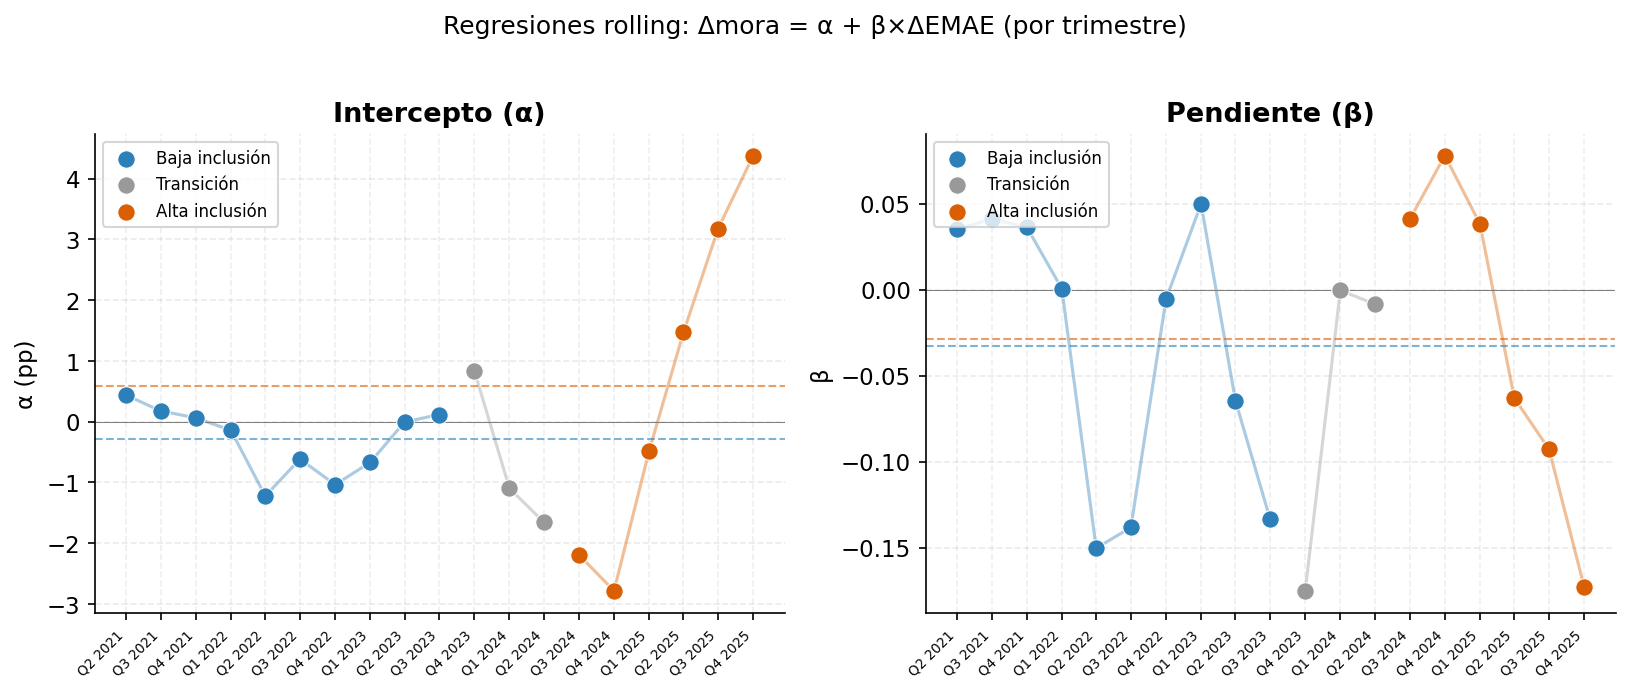

In [94]:
# --- 11c. Evolución de interceptos y pendientes ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

colors_p = {'Baja inclusión': '#2c7fb8', 'Transición': '#999999', 'Alta inclusión': '#d95f02'}

for periodo in ['Baja inclusión', 'Transición', 'Alta inclusión']:
    sub = reg_df[reg_df.periodo == periodo]
    if sub.empty:
        continue
    c = colors_p[periodo]
    for ax_i, var in enumerate(['intercept', 'slope']):
        axes[ax_i].scatter(sub.fecha_q, sub[var], color=c,
                    s=70, zorder=3, label=periodo, edgecolors='white', linewidth=0.5)
        axes[ax_i].plot(sub.fecha_q, sub[var], color=c, alpha=0.4, linewidth=1.5)

# Promedios (solo baja y alta)
for periodo in ['Baja inclusión', 'Alta inclusión']:
    sub = reg_df[reg_df.periodo == periodo]
    c = colors_p[periodo]
    axes[0].axhline(sub.intercept.mean(), color=c, linestyle='--', alpha=0.6, linewidth=1)
    axes[1].axhline(sub.slope.mean(), color=c, linestyle='--', alpha=0.6, linewidth=1)

axes[0].set_title('Intercepto (α)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('α (pp)', fontsize=11)
axes[1].set_title('Pendiente (β)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('β', fontsize=11)

# Eje X con Q1, Q2, etc.
for ax in axes:
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ticks = sorted(reg_df.fecha_q.unique())
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'Q{t.quarter} {t.year}' for t in ticks], fontsize=6.5, rotation=45, ha='right')

fig.suptitle('Regresiones rolling: Δmora = α + β×ΔEMAE (por trimestre)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figuras/fig6_rolling_intercept_slope.png', dpi=200, bbox_inches='tight')
plt.show()


### B. Panel con quiebre estructural

In [95]:
# --- 11e. Opción B: panel con dummy de período ---
# Δmora_it = α₁ + α₂·D_alta + β₁·ΔEMAE_it + β₂·(D_alta·ΔEMAE_it) + ε_it
import statsmodels.api as sm

panel_reg = panel[panel.periodo != 'Transición'].copy()
panel_reg['D_alta'] = (panel_reg.periodo == 'Alta inclusión').astype(int)
panel_reg['emae_x_alta'] = panel_reg.emae_yoy * panel_reg.D_alta

X = sm.add_constant(panel_reg[['emae_yoy', 'D_alta', 'emae_x_alta']])
y = panel_reg['delta_irreg']

model = sm.OLS(y, X).fit(cov_type='HC1')  # robust SE
print(model.summary())
print(f'\n--- Interpretación ---')
print(f'α₁ (intercepto baja inclusión):  {model.params["const"]:.4f} (p={model.pvalues["const"]:.4f})')
print(f'α₂ (cambio en intercepto): {model.params["D_alta"]:.4f} (p={model.pvalues["D_alta"]:.4f})')
print(f'β₁ (pendiente baja inclusión):   {model.params["emae_yoy"]:.4f} (p={model.pvalues["emae_yoy"]:.4f})')
print(f'β₂ (cambio en pendiente):  {model.params["emae_x_alta"]:.4f} (p={model.pvalues["emae_x_alta"]:.4f})')
print(f'\nIntercepto alta inclusión = α₁ + α₂ = {model.params["const"] + model.params["D_alta"]:.4f}')
print(f'Pendiente alta inclusión  = β₁ + β₂ = {model.params["emae_yoy"] + model.params["emae_x_alta"]:.4f}')

                            OLS Regression Results                            
Dep. Variable:            delta_irreg   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.699
Date:                Fri, 17 Apr 2026   Prob (F-statistic):              0.169
Time:                        18:15:47   Log-Likelihood:                -452.59
No. Observations:                 192   AIC:                             913.2
Df Residuals:                     188   BIC:                             926.2
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4404      0.192     -2.293      

### C. Scatter pre vs post (visual)

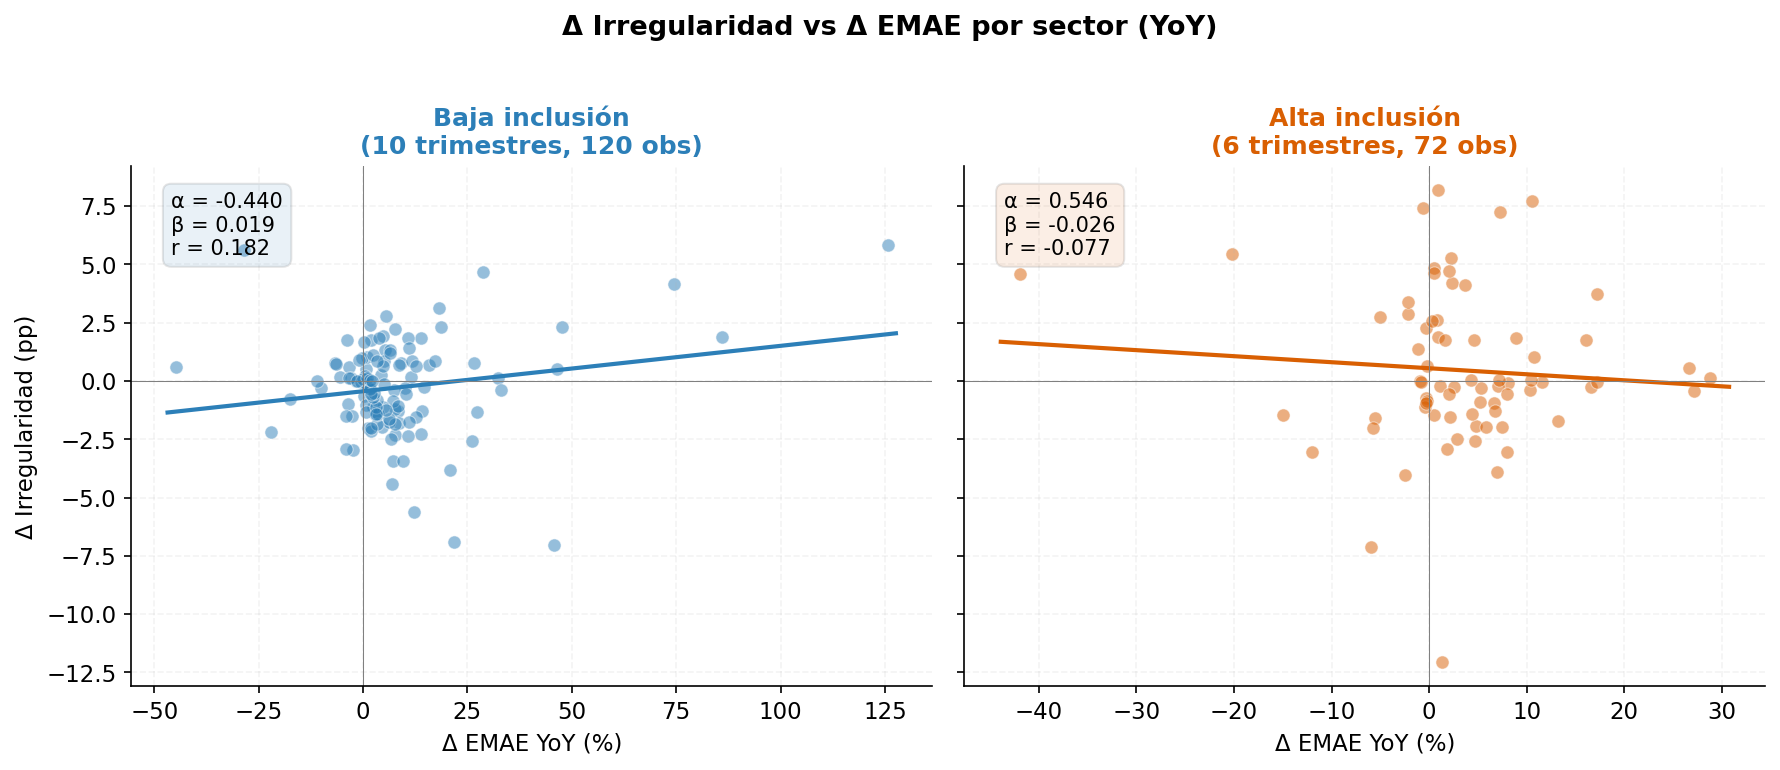

In [96]:
# --- 11f. Opción C: dos scatters lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors_s = {'Baja inclusión': '#2c7fb8', 'Alta inclusión': '#d95f02'}

for i, (periodo, ax) in enumerate(zip(['Baja inclusión', 'Alta inclusión'], axes)):
    sub = panel[panel.periodo == periodo]
    color = colors_s[periodo]
    
    ax.scatter(sub.emae_yoy, sub.delta_irreg, color=color,
               alpha=0.5, s=40, edgecolors='white', linewidth=0.5)
    
    # Regresión
    slope, intercept, r, p, se = stats.linregress(sub.emae_yoy, sub.delta_irreg)
    x_range = np.linspace(sub.emae_yoy.min() - 2, sub.emae_yoy.max() + 2, 100)
    ax.plot(x_range, intercept + slope * x_range, color=color, linewidth=2)
    
    n_q = sub.fecha_q.nunique()
    ax.set_title(f'{periodo}\n({n_q} trimestres, {len(sub)} obs)',
                 fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Δ EMAE YoY (%)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Δ Irregularidad (pp)', fontsize=11)
    
    # Stats box
    textstr = f'α = {intercept:.3f}\nβ = {slope:.3f}\nr = {r:.3f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.1))
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(alpha=0.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Δ Irregularidad vs Δ EMAE por sector (YoY)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figuras/fig8_scatter_pre_post.png', dpi=200, bbox_inches='tight')
plt.show()


### B'. Panel con quiebre estructural + efectos fijos de tiempo

Misma especificación que B, pero con dummies por trimestre para absorber shocks macro comunes.

In [97]:
# --- 11g. Opción B': panel con FE de tiempo ---
import statsmodels.api as sm

panel_fe = panel[panel.periodo != 'Transición'].copy()
panel_fe['D_alta'] = (panel_fe.periodo == 'Alta inclusión').astype(int)
panel_fe['emae_x_alta'] = panel_fe.emae_yoy * panel_fe.D_alta

# Dummies de trimestre (FE de tiempo) — drop_first para evitar colinealidad
time_dummies = pd.get_dummies(panel_fe['fecha_q'], prefix='t', drop_first=True, dtype=float)

# D_alta es combinación lineal de dummies de tiempo → no incluir D_alta directamente.
# El efecto de nivel entre períodos lo absorben los FE de tiempo.
# Lo que SÍ podemos testear es si β cambia entre períodos.
# Modelo: Δmora = α + β₁·ΔEMAE + β₂·(ΔEMAE·D_alta) + γ_t + ε
X_fe = pd.concat([panel_fe[['emae_yoy', 'emae_x_alta']], time_dummies], axis=1)
X_fe = sm.add_constant(X_fe)
y_fe = panel_fe['delta_irreg']

model_fe = sm.OLS(y_fe, X_fe).fit(cov_type='HC1')

print('=== Con FE de tiempo ===')
print(f'{"Variable":20s} {"Coef":>10s} {"SE":>10s} {"p":>8s}')
print('-' * 50)
for var in ['const', 'emae_yoy', 'emae_x_alta']:
    print(f'{var:20s} {model_fe.params[var]:+10.4f} {model_fe.bse[var]:10.4f} {model_fe.pvalues[var]:8.4f}')

print(f'\nR² = {model_fe.rsquared:.4f}')
print(f'N = {int(model_fe.nobs)}')
print(f'FE de tiempo: {len([v for v in model_fe.params.index if v.startswith("t_")])} dummies')

print(f'\n--- Interpretación ---')
print(f'β (baja inclusión):  {model_fe.params["emae_yoy"]:+.4f}  (p={model_fe.pvalues["emae_yoy"]:.4f})')
print(f'β (alta inclusión):  {model_fe.params["emae_yoy"] + model_fe.params["emae_x_alta"]:+.4f}')
print(f'Δβ (alta - baja):    {model_fe.params["emae_x_alta"]:+.4f}  (p={model_fe.pvalues["emae_x_alta"]:.4f})')
print(f'\nNOTA: con FE de tiempo, D_alta (intercepto entre períodos) es colineal con')
print(f'las dummies de trimestre → el efecto de nivel lo absorben los FE.')
print(f'Lo que SÍ identificamos limpiamente es el cambio en la PENDIENTE (β).')

# Modelo SIN interacción para comparar
X_fe0 = pd.concat([panel_fe[['emae_yoy']], time_dummies], axis=1)
X_fe0 = sm.add_constant(X_fe0)
model_fe0 = sm.OLS(y_fe, X_fe0).fit(cov_type='HC1')
print(f'\n--- Sin interacción (β común) ---')
print(f'β = {model_fe0.params["emae_yoy"]:+.4f}  (p={model_fe0.pvalues["emae_yoy"]:.4f})')
print(f'R² = {model_fe0.rsquared:.4f}')

=== Con FE de tiempo ===
Variable                   Coef         SE        p
--------------------------------------------------
const                   +1.2215     0.6446   0.0581
emae_yoy                +0.0101     0.0148   0.4957
emae_x_alta             -0.0597     0.0255   0.0193

R² = 0.4746
N = 192
FE de tiempo: 15 dummies

--- Interpretación ---
β (baja inclusión):  +0.0101  (p=0.4957)
β (alta inclusión):  -0.0496
Δβ (alta - baja):    -0.0597  (p=0.0193)

NOTA: con FE de tiempo, D_alta (intercepto entre períodos) es colineal con
las dummies de trimestre → el efecto de nivel lo absorben los FE.
Lo que SÍ identificamos limpiamente es el cambio en la PENDIENTE (β).

--- Sin interacción (β común) ---
β = -0.0003  (p=0.9835)
R² = 0.4599


### C'. Scatter pre vs post con residuos de FE de tiempo

Para visualizar correctamente, primero removemos el efecto temporal (restamos la media de cada trimestre) y luego graficamos los residuos.

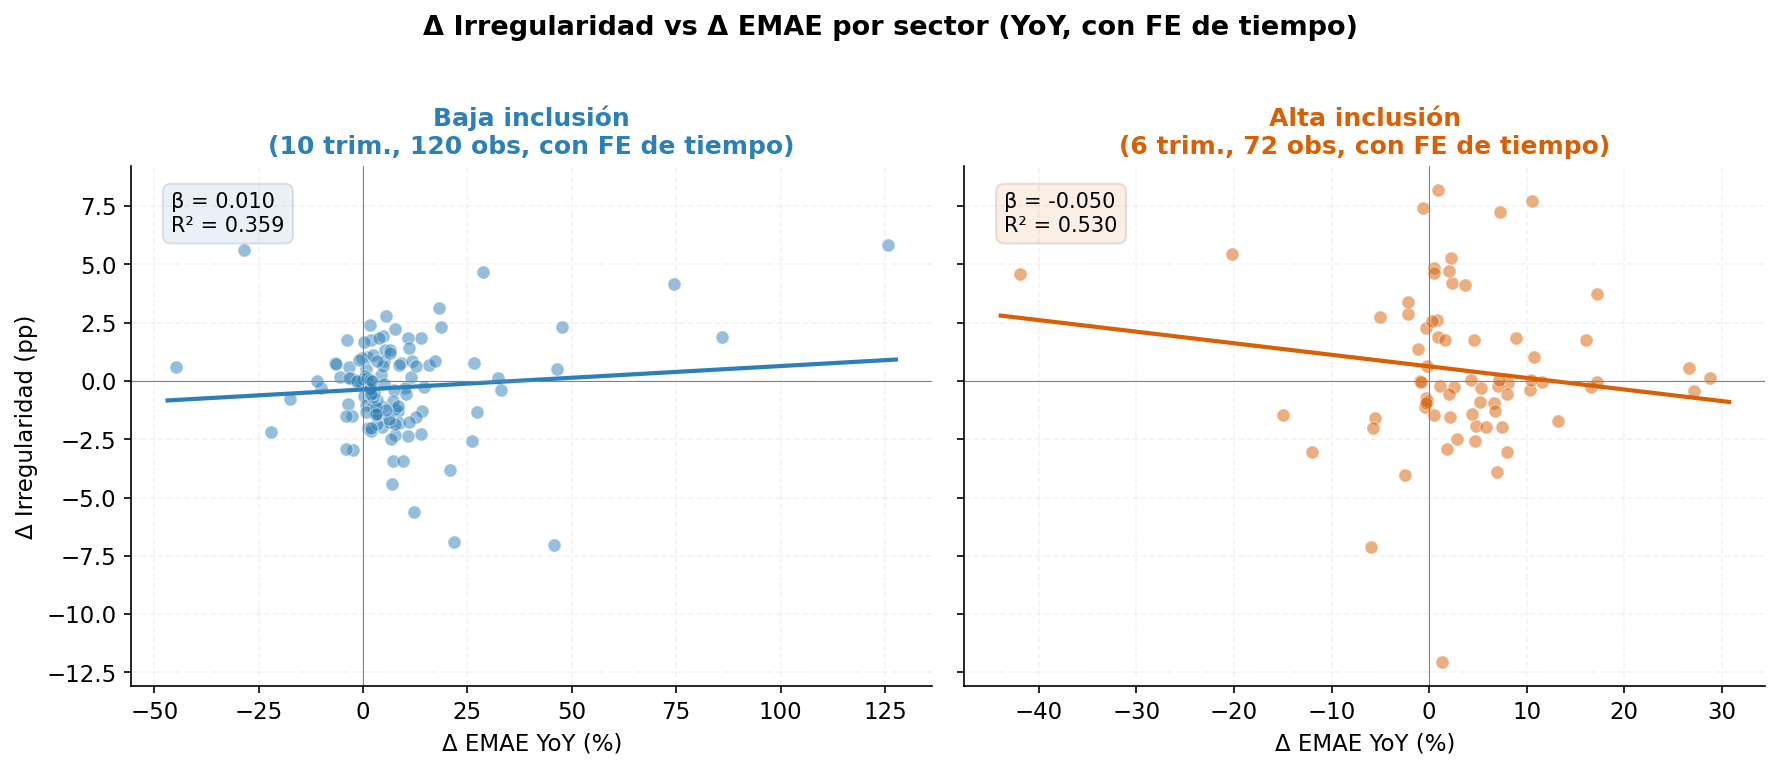

In [98]:
# --- 11h. Opción C': scatter con FE de tiempo (dummies) ---
import statsmodels.api as sm

panel_notr = panel[panel.periodo != 'Transición'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors_s = {'Baja inclusión': '#2c7fb8', 'Alta inclusión': '#d95f02'}

for i, (periodo, ax) in enumerate(zip(['Baja inclusión', 'Alta inclusión'], axes)):
    sub = panel_notr[panel_notr.periodo == periodo].copy()
    color = colors_s[periodo]
    
    # Scatter con datos crudos
    ax.scatter(sub.emae_yoy, sub.delta_irreg, color=color,
               alpha=0.5, s=40, edgecolors='white', linewidth=0.5)
    
    # Regresión con FE de tiempo
    time_dm = pd.get_dummies(sub['fecha_q'], prefix='t', drop_first=True, dtype=float)
    X = pd.concat([sub[['emae_yoy']].reset_index(drop=True), time_dm.reset_index(drop=True)], axis=1)
    X = sm.add_constant(X)
    y = sub['delta_irreg'].reset_index(drop=True)
    model = sm.OLS(y, X).fit()
    
    # Intercepto efectivo = const + promedio de FE de tiempo
    t_cols = [c for c in model.params.index if c.startswith('t_')]
    # Promedio sobre TODOS los trimestres (incluyendo el base cuyo coef=0)
    n_total_q = sub.fecha_q.nunique()
    avg_fe = model.params[t_cols].sum() / n_total_q if t_cols else 0
    intercept_eff = model.params['const'] + avg_fe
    slope = model.params['emae_yoy']
    
    # Línea de regresión (evaluada en el FE promedio)
    x_range = np.linspace(sub.emae_yoy.min() - 2, sub.emae_yoy.max() + 2, 100)
    ax.plot(x_range, intercept_eff + slope * x_range, color=color, linewidth=2)
    
    n_q = sub.fecha_q.nunique()
    ax.set_title(f'{periodo}\n({n_q} trim., {len(sub)} obs, con FE de tiempo)',
                 fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Δ EMAE YoY (%)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Δ Irregularidad (pp)', fontsize=11)
    
    textstr = f'β = {slope:.3f}\nR² = {model.rsquared:.3f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.1))
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(alpha=0.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Δ Irregularidad vs Δ EMAE por sector (YoY, con FE de tiempo)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figuras/fig9_scatter_pre_post_fe.png', dpi=200, bbox_inches='tight')
plt.show()


## 12. Nivel histórico de crédito: ¿dónde estamos?

Para dimensionar el boom crediticio actual, comparamos el stock de crédito al sector privado en dos métricas:

1. **Crédito real** (deflactado por CER, en pesos constantes): elimina el efecto de la inflación.
2. **Crédito / PIB**: mide el peso del crédito relativo a la economía.

**Fuentes:**
- **Crédito**: BCRA – Serie 26 (saldos diarios, millones ARS), promedio mensual.
- **Deflactor**: BCRA – CER (serie 4), coeficiente diario que sigue al IPC.
- **PIB**: INDEC – Cuentas Nacionales, precios corrientes (trimestral anualizado).

In [99]:
# --- 12a. Cargar crédito histórico y CER ---
import urllib.request, json as _json, ssl

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

# CER (serie 4) - deflactor diario continuo que sigue al IPC
cer_records = []
for (desde, hasta) in [('2014-01-01','2017-12-31'), ('2018-01-01','2021-12-31'), ('2022-01-01','2026-04-30')]:
    url = f'https://api.bcra.gob.ar/estadisticas/v4.0/Monetarias/4?desde={desde}&hasta={hasta}'
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, context=ctx, timeout=15) as resp:
        data = _json.loads(resp.read())
    cer_records.extend(data['results'][0]['detalle'])

cer = pd.DataFrame(cer_records)
cer['fecha'] = pd.to_datetime(cer['fecha'], dayfirst=True)
cer = cer.sort_values('fecha').drop_duplicates('fecha').rename(columns={'valor': 'cer'})

# Crédito histórico (serie 26) desde 2014
credito_hist_records = []
for (desde, hasta) in [('2014-01-01','2017-06-30'), ('2017-07-01','2020-12-31'), ('2021-01-01','2023-12-31'), ('2024-01-01','2026-04-30')]:
    url = f'https://api.bcra.gob.ar/estadisticas/v4.0/Monetarias/26?desde={desde}&hasta={hasta}'
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, context=ctx, timeout=15) as resp:
        data = _json.loads(resp.read())
    credito_hist_records.extend(data['results'][0]['detalle'])

credito_hist = pd.DataFrame(credito_hist_records)
credito_hist['fecha'] = pd.to_datetime(credito_hist['fecha'], dayfirst=True)
credito_hist = credito_hist.sort_values('fecha').drop_duplicates('fecha').rename(columns={'valor': 'credito_M'})

print(f'CER: {len(cer)} obs, {cer.fecha.min().date()} a {cer.fecha.max().date()}')
print(f'Crédito: {len(credito_hist)} obs, {credito_hist.fecha.min().date()} a {credito_hist.fecha.max().date()}')

CER: 2948 obs, 2014-01-02 a 2026-04-17
Crédito: 2987 obs, 2014-01-02 a 2026-04-15


In [100]:
# --- 12b. Crédito real (deflactado por CER) ---
credito_hist['ym'] = credito_hist.fecha.dt.to_period('M')
cer['ym'] = cer.fecha.dt.to_period('M')

cred_m = credito_hist.groupby('ym')['credito_M'].mean().reset_index()
cer_m = cer.groupby('ym')['cer'].mean().reset_index()

cred_real = cred_m.merge(cer_m, on='ym', how='inner')
cred_real['fecha'] = cred_real.ym.dt.to_timestamp()

# Base = último mes disponible (pesos constantes del último mes)
cer_base = cred_real['cer'].iloc[-1]
cred_real['credito_real'] = cred_real['credito_M'] / cred_real['cer'] * cer_base

# Promedios
avg_5y = cred_real[cred_real.fecha >= '2021-01-01']['credito_real'].mean()
avg_10y = cred_real[cred_real.fecha >= '2016-01-01']['credito_real'].mean()
latest = cred_real.iloc[-1]['credito_real']

print(f'Crédito real: {len(cred_real)} meses')
print(f'Promedio 5 años:  {avg_5y/1e6:,.1f} (en millones de ARS constantes)')
print(f'Promedio 10 años: {avg_10y/1e6:,.1f}')
print(f'Último dato:      {latest/1e6:,.1f}')
print(f'vs prom 5a:  {(latest/avg_5y - 1)*100:+.0f}%')
print(f'vs prom 10a: {(latest/avg_10y - 1)*100:+.0f}%')

Crédito real: 146 meses
Promedio 5 años:  68.0 (en millones de ARS constantes)
Promedio 10 años: 74.6
Último dato:      124.2
vs prom 5a:  +83%
vs prom 10a: +66%


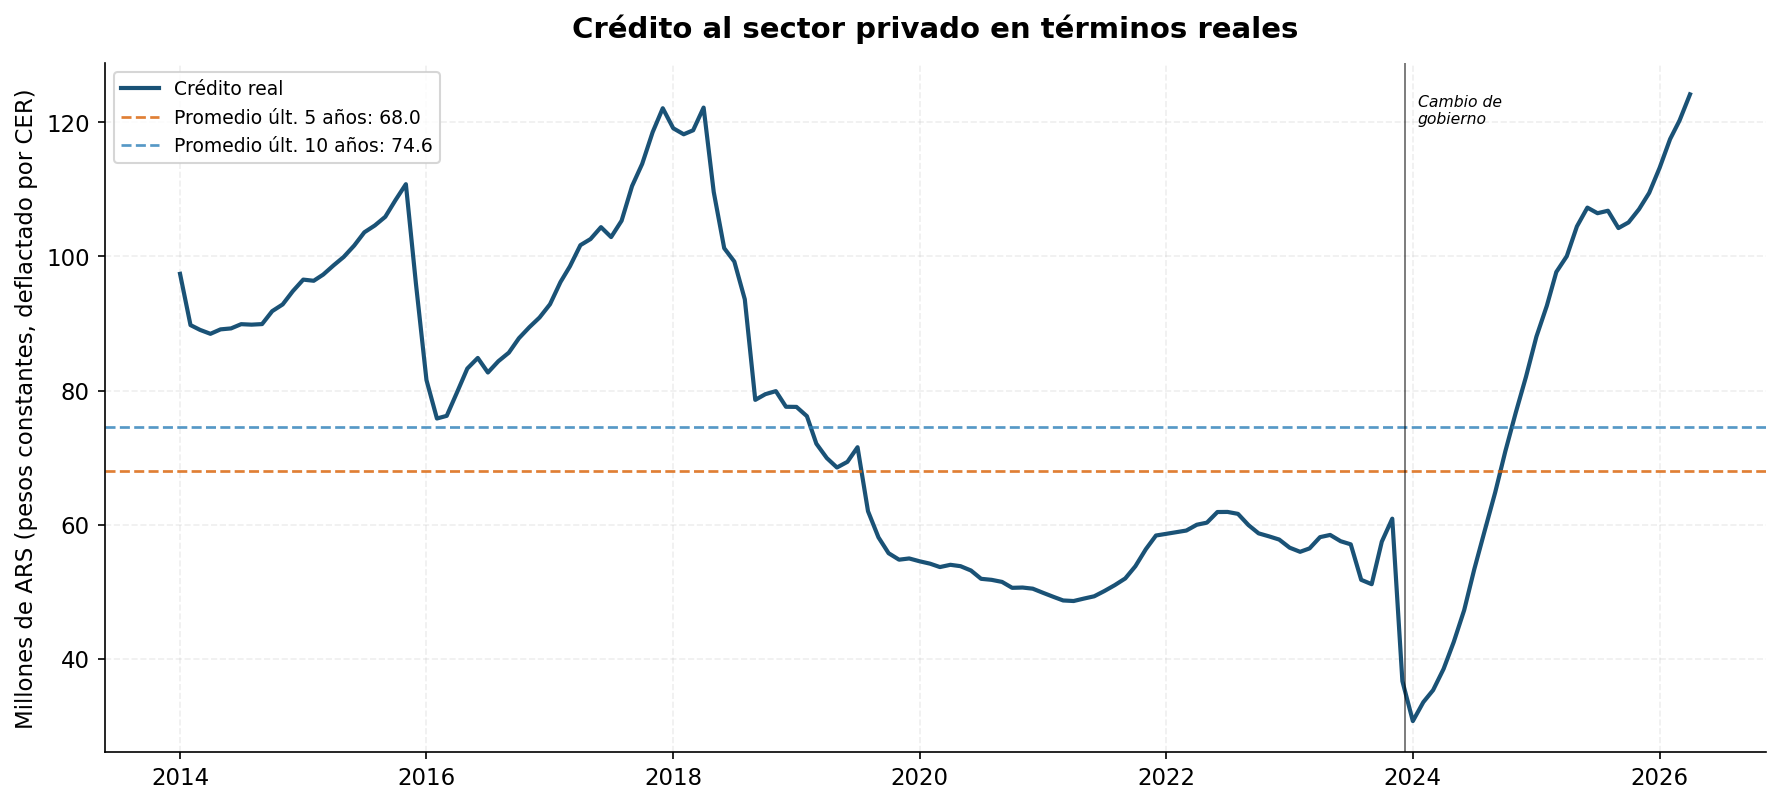

In [101]:
# --- 12c. Gráfico: Crédito real ---
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(cred_real.fecha, cred_real.credito_real / 1e6, '-',
        color='#1a5276', linewidth=2, label='Crédito real')
ax.axhline(avg_5y / 1e6, color='#d95f02', linestyle='--', linewidth=1.3,
           label=f'Promedio últ. 5 años: {avg_5y/1e6:,.1f}', alpha=0.8)
ax.axhline(avg_10y / 1e6, color='#2c7fb8', linestyle='--', linewidth=1.3,
           label=f'Promedio últ. 10 años: {avg_10y/1e6:,.1f}', alpha=0.8)

ax.set_ylabel('Millones de ARS (pesos constantes, deflactado por CER)', fontsize=11)
ax.set_title('Crédito al sector privado en términos reales',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='upper left')

# Cambio de gobierno
ax.axvline(pd.Timestamp('2023-12-10'), color='black', linewidth=0.8, alpha=0.6)
ax.text(pd.Timestamp('2024-01-15'), ax.get_ylim()[1]*0.93,
        'Cambio de\ngobierno', fontsize=7.5, style='italic')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('figuras/fig10_credito_real.png', dpi=200, bbox_inches='tight')
plt.show()


In [102]:
# --- 12d. Crédito / PIB histórico (desde 2014) ---
pib_full = pd.read_csv('datos/pib_trimestral_corrientes.csv')
pib_full = pib_full[['indice_tiempo', 'producto_interno_bruto_precios_mercado']].copy()
pib_full.columns = ['fecha', 'pib_M']
pib_full['fecha'] = pd.to_datetime(pib_full['fecha'])
pib_full = pib_full.sort_values('fecha').reset_index(drop=True)

credito_hist['year'] = credito_hist.fecha.dt.year
credito_hist['quarter'] = credito_hist.fecha.dt.quarter
q_month = {1: 1, 2: 4, 3: 7, 4: 10}
cred_q_hist = credito_hist.groupby(['year','quarter'])['credito_M'].mean().reset_index()
cred_q_hist['fecha_q'] = cred_q_hist.apply(
    lambda r: pd.Timestamp(year=int(r['year']), month=q_month[int(r['quarter'])], day=1), axis=1)

ratio_hist = cred_q_hist.merge(pib_full, left_on='fecha_q', right_on='fecha', how='inner')
ratio_hist['cred_pib'] = ratio_hist['credito_M'] / ratio_hist['pib_M'] * 100

avg_ratio_5y = ratio_hist[ratio_hist.fecha_q >= '2021-01-01']['cred_pib'].mean()
avg_ratio_10y = ratio_hist[ratio_hist.fecha_q >= '2016-01-01']['cred_pib'].mean()

print(f'Serie crédito/PIB: {len(ratio_hist)} trimestres')
print(f'Promedio 5 años:  {avg_ratio_5y:.1f}%')
print(f'Promedio 10 años: {avg_ratio_10y:.1f}%')
print(f'Último dato:      {ratio_hist.iloc[-1].cred_pib:.1f}%')


Serie crédito/PIB: 48 trimestres
Promedio 5 años:  7.7%
Promedio 10 años: 9.6%
Último dato:      11.9%


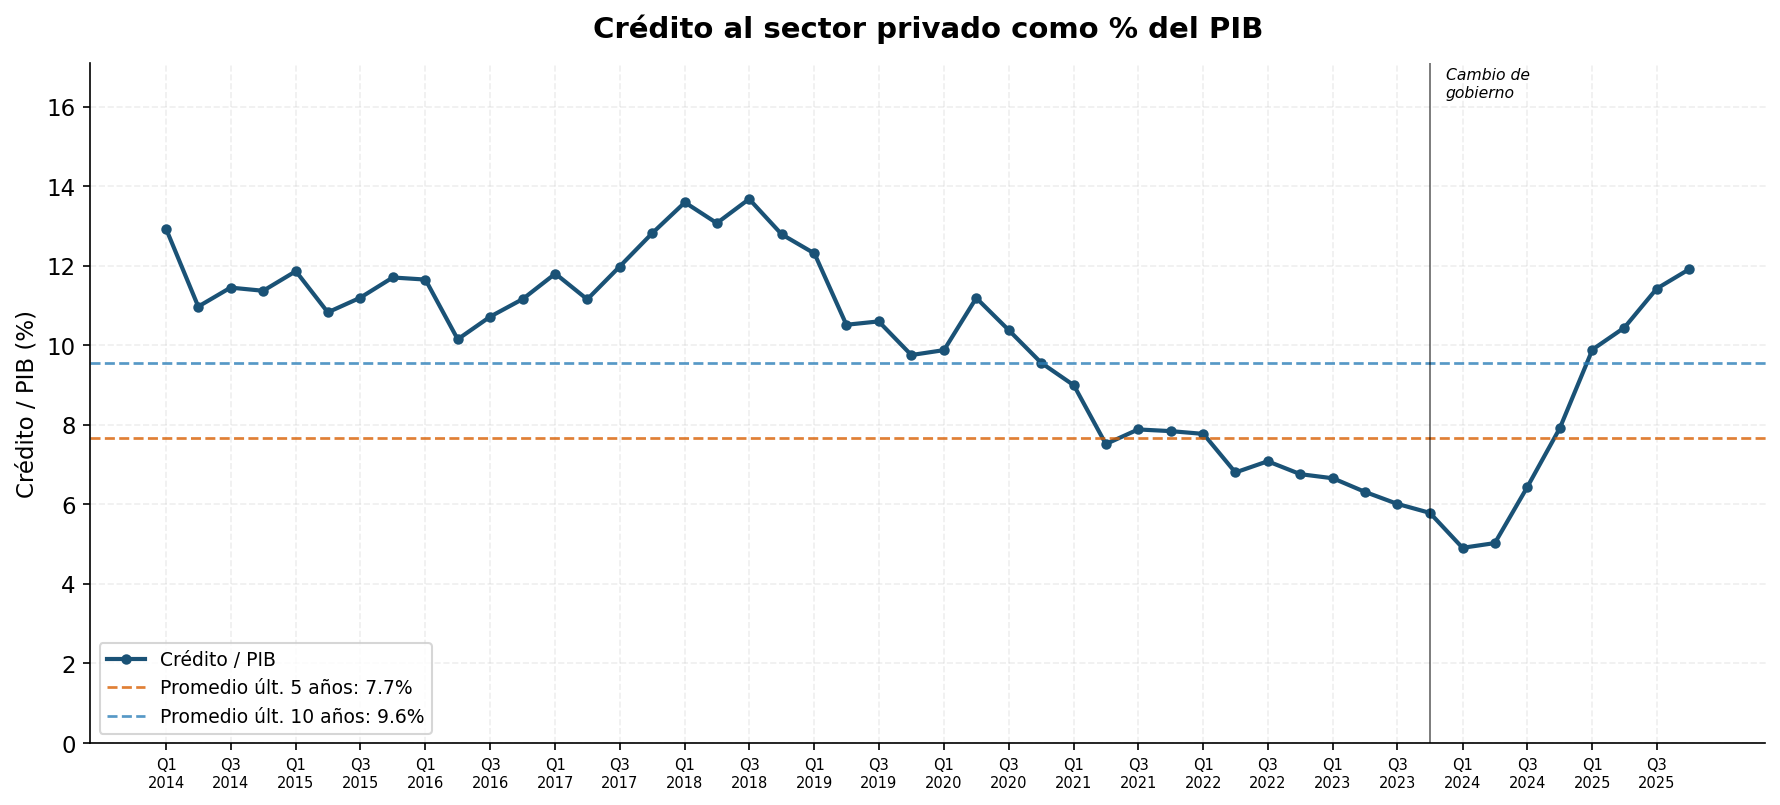

In [103]:
# --- 12e. Gráfico: Crédito / PIB histórico ---
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(ratio_hist.fecha_q, ratio_hist.cred_pib, 'o-',
        color='#1a5276', linewidth=2, markersize=4, label='Crédito / PIB')
ax.axhline(avg_ratio_5y, color='#d95f02', linestyle='--', linewidth=1.3,
           label=f'Promedio últ. 5 años: {avg_ratio_5y:.1f}%', alpha=0.8)
ax.axhline(avg_ratio_10y, color='#2c7fb8', linestyle='--', linewidth=1.3,
           label=f'Promedio últ. 10 años: {avg_ratio_10y:.1f}%', alpha=0.8)

ax.set_ylabel('Crédito / PIB (%)', fontsize=11)
ax.set_title('Crédito al sector privado como % del PIB',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(0, ratio_hist.cred_pib.max() * 1.25)

# Cambio de gobierno
ax.axvline(pd.Timestamp('2023-10-01'), color='black', linewidth=0.8, alpha=0.6)
ax.text(pd.Timestamp('2023-11-15'), ax.get_ylim()[1]*0.95,
        'Cambio de\ngobierno', fontsize=7.5, style='italic')

# X labels
ticks = ratio_hist.fecha_q.values[::2]
ax.set_xticks(ticks)
ax.set_xticklabels([f'Q{pd.Timestamp(t).quarter}\n{pd.Timestamp(t).year}' for t in ticks], fontsize=7)

plt.tight_layout()
plt.savefig('figuras/fig11_credito_pib_historico.png', dpi=200, bbox_inches='tight')
plt.show()
